Using device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total Sentences Loaded: 13813

Sample Sentence:
['Sehr', 'gute', 'Beratung', ',', 'schnelle', 'Behebung', 'der', 'Probleme', ',', 'so', 'stelle', 'ich', 'mir', 'Kundenservice', 'vor', '.']

BERT Tokens:
['[CLS]', 'Se', '##hr', 'gute', 'Be', '##ratu', '##ng', ',', 'schnell', '##e', 'Be', '##hebung', 'der', 'Probleme', ',', 'so', 'stelle', 'ich', 'mir', 'Kunden', '##ser', '##vice', 'vor', '.', '[SEP]']

Alignment Mapping:
{1: [1, 2], 2: [3], 3: [4, 5, 6], 4: [7], 5: [8, 9], 6: [10, 11], 7: [12], 8: [13], 9: [14], 10: [15], 11: [16], 12: [17], 13: [18], 14: [19, 20, 21], 15: [22], 16: [23]}


100%|██████████| 1000/1000 [07:10<00:00,  2.32it/s]



BEST HEAD FOUND:
Layer       7.000000
Head        9.000000
Accuracy    0.620486
Name: 80, dtype: float64


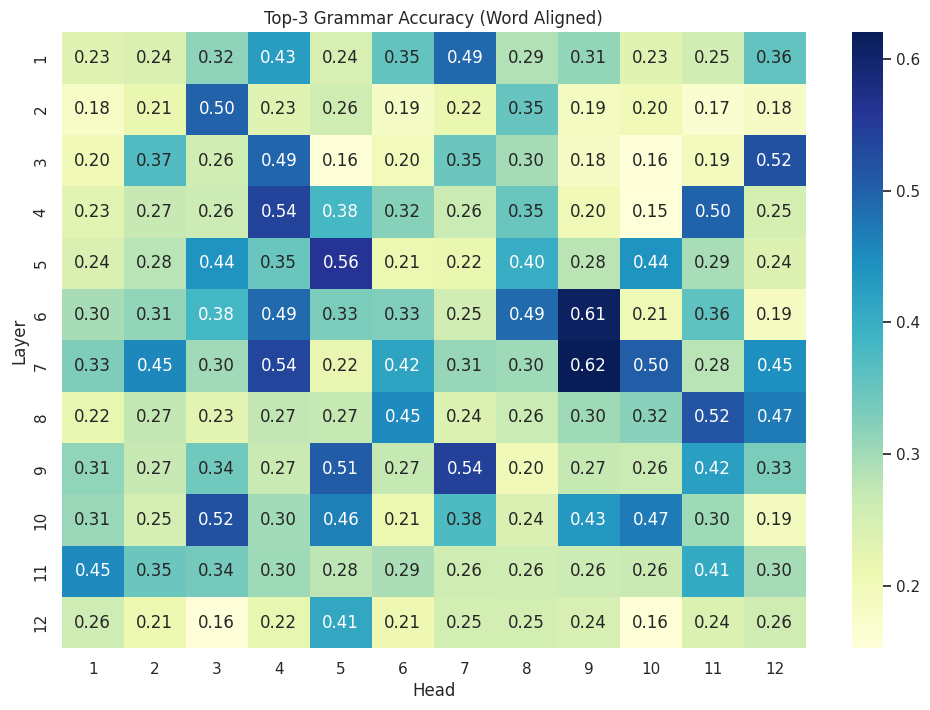

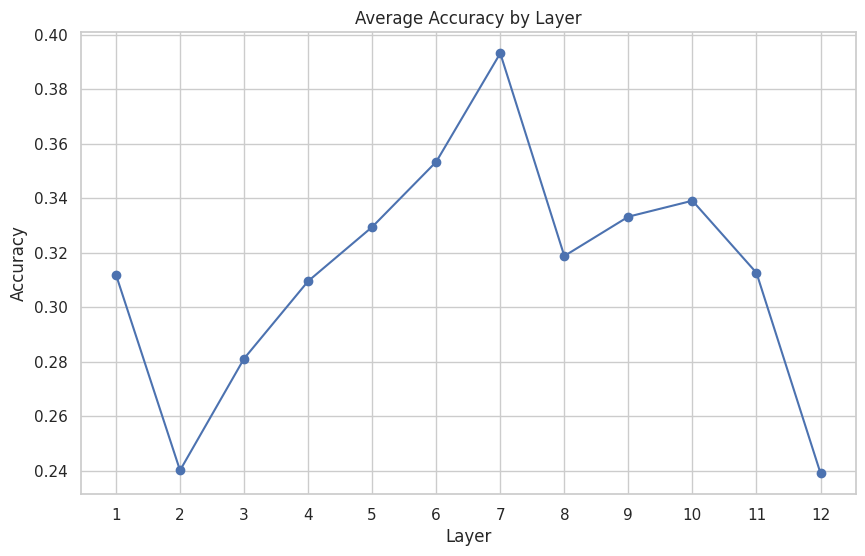


Saved File: bert_top3_word_aligned_results.csv


In [3]:

# 1. Top-3 scoring instead of Top-1 german
# 2. Subword-to-word alignment for BERT tokens


!pip -q install transformers torch conllu requests seaborn matplotlib pandas numpy tqdm


import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

from tqdm import tqdm
from conllu import parse
from transformers import BertTokenizer, BertModel

sns.set(style="whitegrid")

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


tokenizer = BertTokenizer.from_pretrained("bert-base-multilingual-cased")

model = BertModel.from_pretrained(
    "bert-base-multilingual-cased",
    output_attentions=True
)

model.to(device)
model.eval()


url = "https://raw.githubusercontent.com/UniversalDependencies/UD_German-GSD/master/de_gsd-ud-train.conllu"

data = requests.get(url).text
sentences = parse(data)

print("Total Sentences Loaded:", len(sentences))


def tokenize_with_alignment(words):
    """
    Converts word list into BERT tokens
    Also stores mapping:
    word index -> list of subword token positions
    """

    bert_tokens = ["[CLS]"]
    mapping = {}

    current_pos = 1   

    for i, word in enumerate(words, start=1):

        sub_tokens = tokenizer.tokenize(word)

        mapping[i] = list(range(current_pos, current_pos + len(sub_tokens)))

        bert_tokens.extend(sub_tokens)

        current_pos += len(sub_tokens)

    bert_tokens.append("[SEP]")

    return bert_tokens, mapping



def get_attention(words):

    sentence = " ".join(words)

    inputs = tokenizer(
        sentence,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )

    inputs = {k:v.to(device) for k,v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    attentions = outputs.attentions

    bert_tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    return attentions, bert_tokens



def convert_to_word_matrix(attn_matrix, mapping, num_words):
    """
    Converts token-token attention matrix
    into word-word attention matrix
    by averaging subword attentions
    """

    word_matrix = np.zeros((num_words+1, num_words+1))

    for child_word in range(1, num_words+1):

        child_tokens = mapping[child_word]

        for parent_word in range(1, num_words+1):

            parent_tokens = mapping[parent_word]

            vals = []

            for ct in child_tokens:
                for pt in parent_tokens:
                    vals.append(attn_matrix[ct][pt])

            word_matrix[child_word][parent_word] = np.mean(vals)

    return word_matrix



def top3_score(word_matrix, gold_heads):
    """
    If gold parent in top 3 attention targets => correct
    """

    correct = 0
    total = 0

    num_words = len(gold_heads)

    for child in range(1, num_words+1):

        gold_parent = gold_heads[child-1]

        if gold_parent == 0:
            continue

        row = word_matrix[child][1:]  

        top3 = np.argsort(row)[-3:] + 1

        if gold_parent in top3:
            correct += 1

        total += 1

    if total == 0:
        return 0

    return correct / total



sample = sentences[0]

words = [token["form"] for token in sample]
heads = [token["head"] for token in sample]

print("\nSample Sentence:")
print(words)

attentions, bert_tokens = get_attention(words)

print("\nBERT Tokens:")
print(bert_tokens)

bert_tokens2, mapping = tokenize_with_alignment(words)

print("\nAlignment Mapping:")
print(mapping)


NUM_SENTENCES = 1000

all_scores = []

for idx in tqdm(range(NUM_SENTENCES)):

    try:
        sample = sentences[idx]

        words = [token["form"] for token in sample]
        heads = [token["head"] for token in sample]

        
        if len(words) < 3:
            continue

        
        if len(words) > 40:
            continue

        attentions, bert_tokens = get_attention(words)

        _, mapping = tokenize_with_alignment(words)

        num_words = len(words)

        for layer in range(12):
            for head in range(12):

                token_matrix = attentions[layer][0, head].cpu().numpy()

                word_matrix = convert_to_word_matrix(
                    token_matrix,
                    mapping,
                    num_words
                )

                acc = top3_score(word_matrix, heads)

                all_scores.append([layer+1, head+1, acc])

    except:
        continue


df = pd.DataFrame(
    all_scores,
    columns=["Layer", "Head", "Accuracy"]
)

avg_df = df.groupby(
    ["Layer","Head"]
)["Accuracy"].mean().reset_index()


best = avg_df.sort_values(
    "Accuracy",
    ascending=False
).iloc[0]

print("\nBEST HEAD FOUND:")
print(best)


pivot = avg_df.pivot(
    index="Layer",
    columns="Head",
    values="Accuracy"
)

plt.figure(figsize=(12,8))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Top-3 Grammar Accuracy (Word Aligned)")
plt.xlabel("Head")
plt.ylabel("Layer")
plt.show()


layer_avg = avg_df.groupby("Layer")["Accuracy"].mean().reset_index()

plt.figure(figsize=(10,6))
plt.plot(
    layer_avg["Layer"],
    layer_avg["Accuracy"],
    marker="o"
)

plt.title("Average Accuracy by Layer")
plt.xlabel("Layer")
plt.ylabel("Accuracy")
plt.xticks(range(1,13))
plt.show()


avg_df.to_csv("bert_top3_word_aligned_results.csv", index=False)

print("\nSaved File: bert_top3_word_aligned_results.csv")